# Short EDA for diabetes dataset

In [172]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns

In [173]:
# reading dataset
df = pd.read_csv('diabetes.csv')

In [174]:
# 5 random samles
df.sample(5, random_state=20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
143,10,108,66,0,0,32.4,0.272,42,1
14,5,166,72,19,175,25.8,0.587,51,1
504,3,96,78,39,0,37.3,0.238,40,0
557,8,110,76,0,0,27.8,0.237,58,0
736,0,126,86,27,120,27.4,0.515,21,0


In [175]:
# info about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [176]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


####  From describe we see zeros in Glucose	BloodPressure SkinThickness Insulin BMI - it`s missining values

In [177]:
#columns with zeros
cols_with_zeros = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'SkinThickness']

# using median for missining values
df[cols_with_zeros] = (df[cols_with_zeros]
                       .replace(0, df[cols_with_zeros][df[cols_with_zeros] > 0]
                       .median())
                    )

In [178]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### Number of samples ​​with class 0 and 1

<Axes: xlabel='Outcome', ylabel='count'>

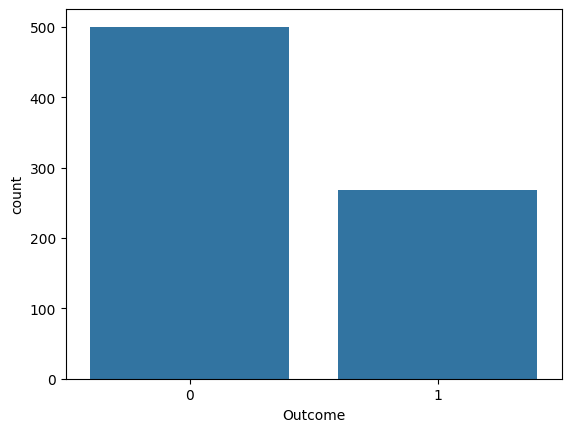

In [179]:
sns.countplot(data=df, x='Outcome')

#### Correlation map

<Axes: >

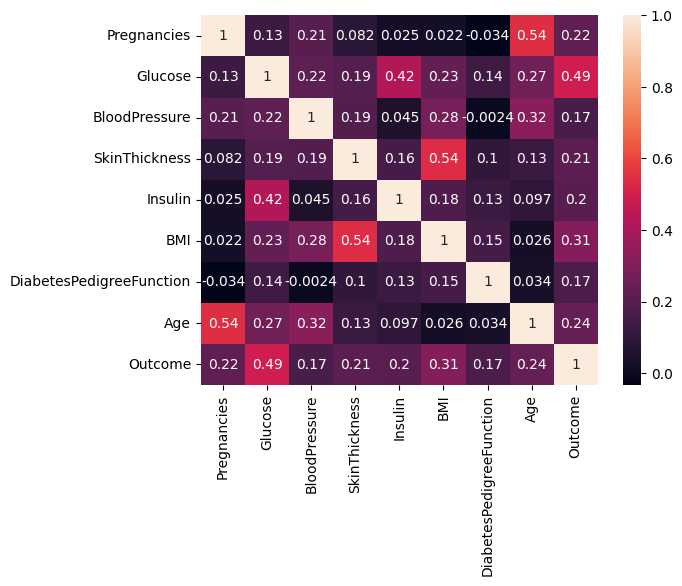

In [180]:
sns.heatmap(df.corr(), annot=True)

###

# Models

#### Dataset spliting and standardization

In [181]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X, y
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)


# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Shapes:\nTrain X: {X_train_scaled.shape} Train y: {y_train.shape}\nTest X: {X_test_scaled.shape} Test y: {y_test.shape}')

Shapes:
Train X: (576, 8) Train y: (576,)
Test X: (192, 8) Test y: (192,)


## Logistic regresion and metrics

In [182]:
from sklearn.linear_model import LogisticRegression

#training, predicting and get score of y
log_model = LogisticRegression().fit(X_train_scaled, y_train) # Намагався підвищити точність моделі підбором С, але залишив як є бо вагомого результату не дало
y_pred = (log_model.predict_proba(X_test_scaled)[:, 1] > 0.4).astype(int)
y_score = log_model.decision_function(X_test_scaled)

#### Confusion matrix

array([[102,  28],
       [ 20,  42]])

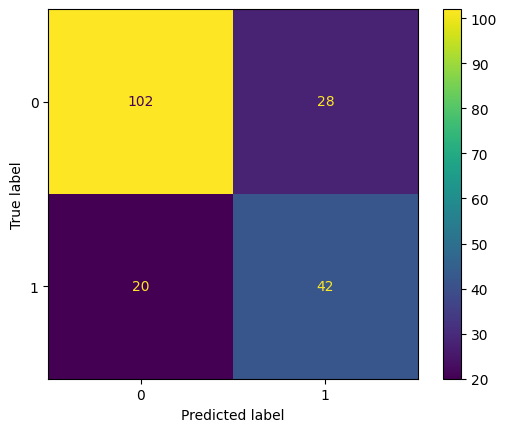

In [183]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
confusion_matrix(y_test, y_pred)

#### Precision score, recall score, f1 score, accuracy

In [184]:
# metrics
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print(f'Scores:\nF1: {f1_score(y_test, y_pred)}\nRecall: {recall_score(y_test, y_pred)}\nPrecision: {precision_score(y_test, y_pred)}\nAccuracy: {accuracy_score(y_test, y_pred)}')

Scores:
F1: 0.6363636363636364
Recall: 0.6774193548387096
Precision: 0.6
Accuracy: 0.75


#### Clasification report

In [185]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       130
           1       0.60      0.68      0.64        62

    accuracy                           0.75       192
   macro avg       0.72      0.73      0.72       192
weighted avg       0.76      0.75      0.75       192



#### Precisoin Recall Curve

Text(0, 0.5, 'Recall')

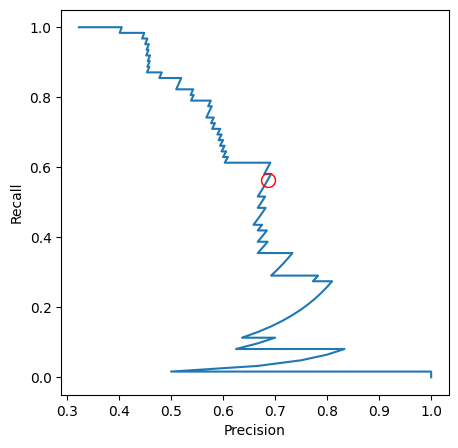

In [186]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# searching 
closest_zero = np.argmin(np.abs(thresholds))
closest_p = precision[closest_zero]
closest_r = recall[closest_zero]

fig, axs = plt.subplots(figsize=(5, 5), dpi=100)
axs.plot(precision, recall)
axs.plot(closest_p, closest_r, 'o', markersize=10, color='red', fillstyle='none')
axs.set_xlabel('Precision')
axs.set_ylabel('Recall')


 #### RocCurve

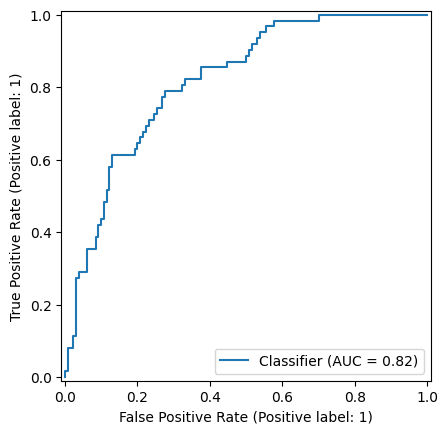

In [187]:
from sklearn.metrics import RocCurveDisplay

# Class for display RoCurve from predictions
RocCurveDisplay.from_predictions(y_test, y_score) # Якщоб цей графік був ніби бука Г, було б ідеально, прочитав в інетернеті якщо не так дайте фідбек

#### Pobability for 0 and 1

In [188]:
probs = log_model.predict_proba(X_test_scaled)

df_proba = pd.DataFrame({'true_value':  y_test, 'predicted': y_pred,'probability of 0': probs[:, 0],'probability of 1': probs[:, 1]})
df_proba.sample(15, random_state=42)


,true_value,predicted,probability of 0,probability of 1
187,1,1,0.589055,0.410945
479,0,0,0.667464,0.332536
763,0,0,0.650804,0.349196
392,0,0,0.929581,0.070419
749,1,1,0.407675,0.592325
313,0,0,0.764590,0.235410
403,0,0,0.909595,0.090405
150,0,1,0.588773,0.411227
526,0,0,0.977756,0.022244
92,0,1,0.593030,0.406970


## Dummy classificator

In [189]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent').fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)

#### Confusion matrix

array([[130,   0],
       [ 62,   0]])

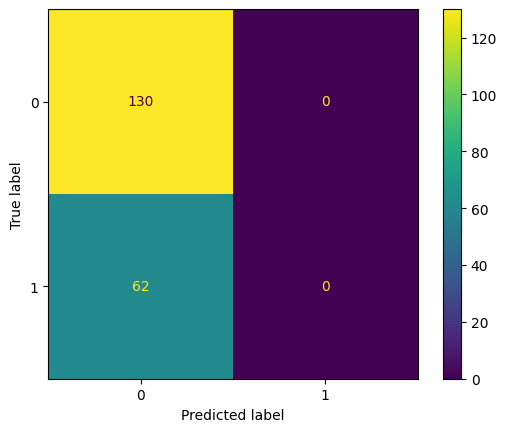

In [190]:
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, dummy_pred)
confusion_matrix(y_test, dummy_pred)

#### Classification report

In [191]:
#from sklearn.metrics import classification_report

print(classification_report(y_test, dummy_pred))

              precision    recall  f1-score   support

           0       0.68      1.00      0.81       130
           1       0.00      0.00      0.00        62

    accuracy                           0.68       192
   macro avg       0.34      0.50      0.40       192
weighted avg       0.46      0.68      0.55       192



/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Multiclassification with Desicion Tree (wine dataset)

#### Reading dataset, and spliting

In [192]:
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




#### training and predict

In [193]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

d_tree_model = DecisionTreeClassifier(criterion='gini', max_depth=3).fit(X_train_scaled, y_train)

y_pred = d_tree_model.predict(X_test_scaled)


#### Probabilitys for 0, 1, 2 clases

In [194]:
probs = d_tree_model.predict_proba(X_test_scaled)

df_proba = pd.DataFrame({'true_value':  y_test, 'predicted': y_pred,'probability of 0': probs[:, 0],'probability of 1': probs[:, 1], 'probability of 2': probs[:, 2]})

df_proba



,true_value,predicted,probability of 0,probability of 1,probability of 2
0,1,1,0.0,0.976744,0.023256
1,2,2,0.0,0.000000,1.000000
2,0,0,1.0,0.000000,0.000000
3,1,1,0.0,0.976744,0.023256
4,1,1,0.0,0.976744,0.023256
5,1,1,0.0,0.750000,0.250000
6,2,1,0.0,0.976744,0.023256
7,1,1,0.0,0.976744,0.023256
8,1,1,0.0,0.976744,0.023256
9,2,2,0.0,0.000000,1.000000


#### Classification report

In [195]:
#from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88        13
           1       0.87      0.91      0.89        22
           2       0.90      0.90      0.90        10

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



#### Confusion matrix

array([[11,  2,  0],
       [ 1, 20,  1],
       [ 0,  1,  9]])

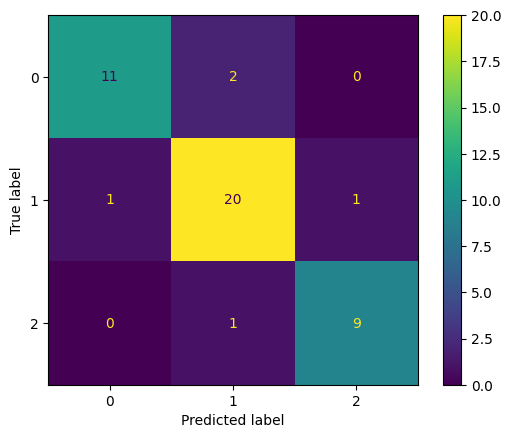

In [196]:
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
confusion_matrix(y_test, y_pred)

#### Avarage metrics

In [197]:
#from sklearn.metrics import f1_score, recall_score, precision_score

# Avarage presicion
print(f'Micro-averaged precision: {precision_score(y_test, y_pred, average = 'micro')}')
print(f'Micro-averaged precision: {precision_score(y_test, y_pred, average = 'macro')}\n')

# Avarage Recall
print(f'Micro-averaged recall: {recall_score(y_test, y_pred, average = 'micro')}')
print(f'Micro-averaged recall: {recall_score(y_test, y_pred, average = 'macro')}\n')

# Avarage F1 - score
print(f'Micro-averaged f1 - score: {f1_score(y_test, y_pred, average = 'micro')}')
print(f'Micro-averaged f1 - score: {f1_score(y_test, y_pred, average = 'macro')}')

Micro-averaged precision: 0.8888888888888888
Micro-averaged precision: 0.8954106280193237

Micro-averaged recall: 0.8888888888888888
Micro-averaged recall: 0.8850815850815851

Micro-averaged f1 - score: 0.8888888888888888
Micro-averaged f1 - score: 0.8896296296296295


#### Tree

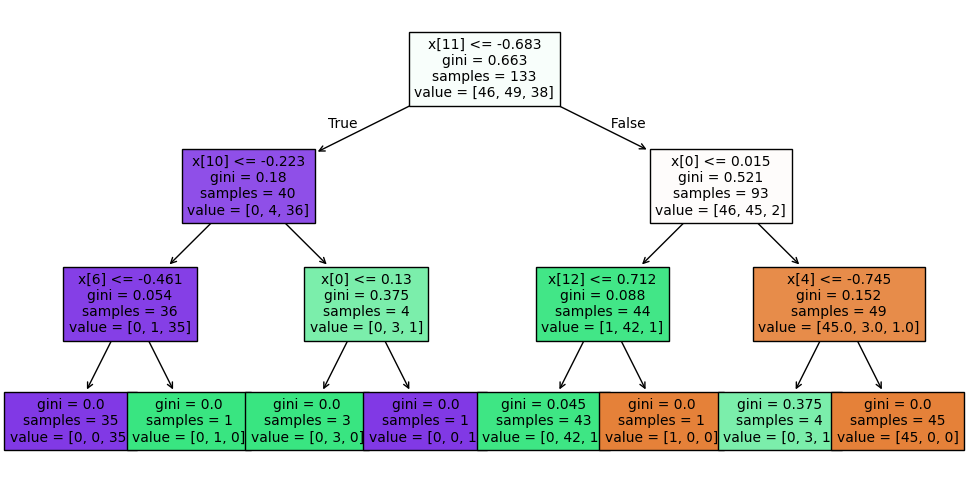

In [198]:
# ploting tree
plt.figure(figsize=(10, 5), dpi=100)
plot_tree(
    d_tree_model,
    filled=True,
    fontsize=10
)
plt.tight_layout()

## Linear regresion and metrics

#### Reading dataset

In [199]:
df = (pd
      .read_csv('Student_Performance.csv')
      .drop('Extracurricular Activities', axis=1)
      )

df.head(5)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


#### Correlation map

<Axes: >

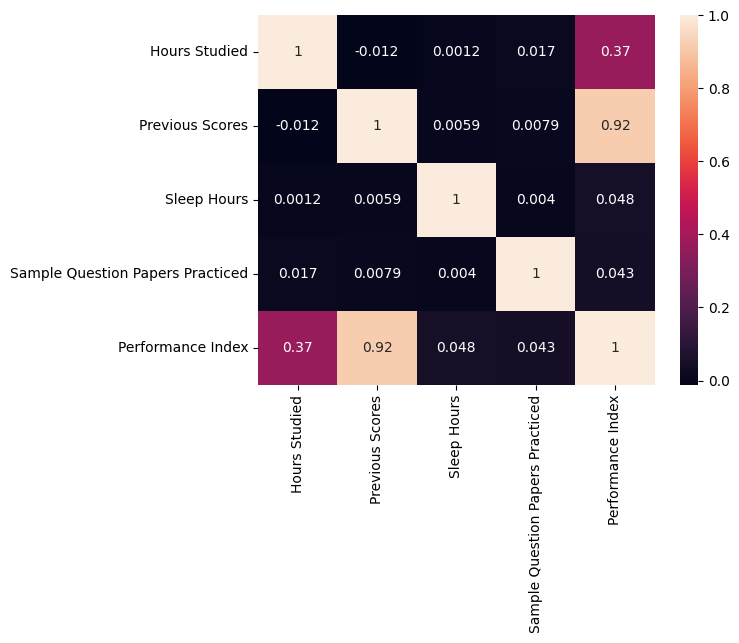

In [200]:
sns.heatmap(df.corr(), annot=True) # Бачимо що Previous Scores, Spleep Hours не корелюють з таргетомd

#### Spliting and scaling

In [201]:
X, y = df[['Hours Studied', 'Previous Scores']], df['Performance Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Training and predicting

In [202]:
from sklearn.linear_model import LinearRegression

lin_regresion = LinearRegression().fit(X_train_scaled, y_train)

y_pred = lin_regresion.predict(X_test_scaled)

#### RMSE, MAE, MSE, R2 - score

In [203]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error

print(f'MSE: {mean_squared_error(y_test, y_pred)}\nMAE: {mean_absolute_error(y_test, y_pred)}\nRMSE: {root_mean_squared_error(y_test, y_pred)}\nR2-score: {r2_score(y_test, y_pred)}\n')

MSE: 5.181238799305428
MAE: 1.798893131665323
RMSE: 2.2762334676621876
R2-score: 0.9858757114037683



#### Residual

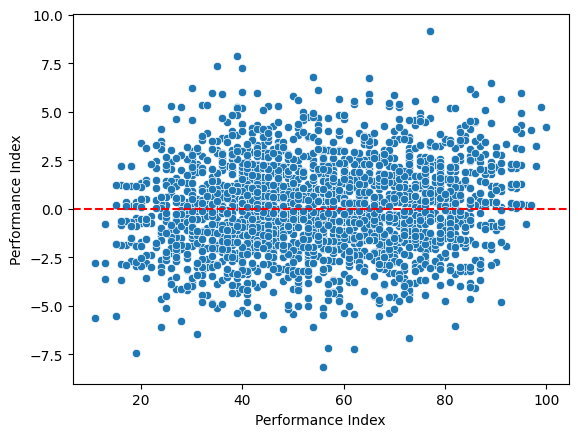

In [204]:
test_residual = y_test - y_pred

sns.scatterplot(x=y_test, y=test_residual)
plt.axhline(y=0, ls='--', color='red')

# Досліджував це в інетрнеті, якщо є якась видима структура то це погано, також по цьому хочу фідбек

#### Distribution of residuals

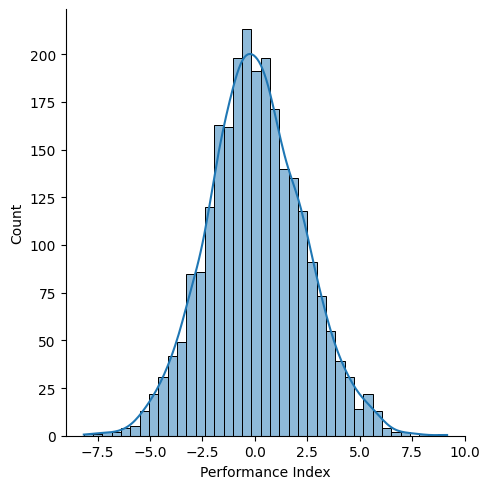

In [205]:
sns.displot(test_residual, kde=True) # Якщо зосереджено біля 0 і форма як дзвоник то це гуд

#### Normal probability plot

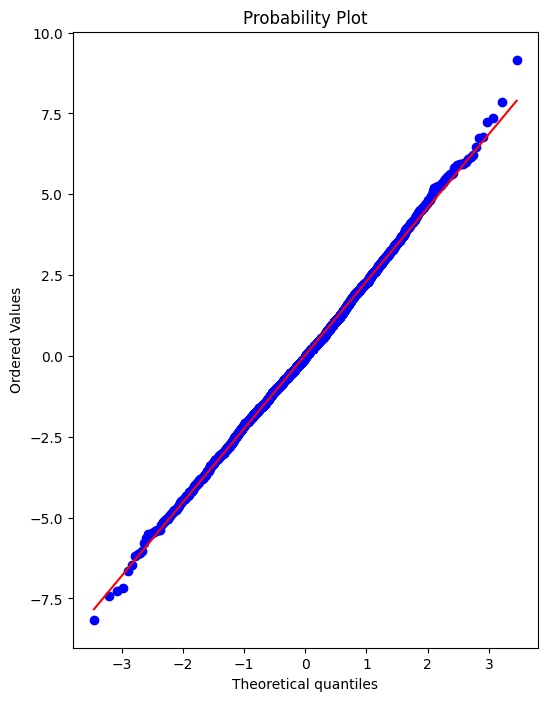

In [206]:
import scipy as sp

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)

_ = sp.stats.probplot(test_residual, plot=ax) # Якщо точки близько до діагоналі а бо є на нійб то це добре